In [3]:
import sys
import numpy as np
from astropy import units as u
from scipy.integrate import quad
sys.path.append("..")
from astropy.cosmology import FlatLambdaCDM
import emcee
import matplotlib.pyplot as plt
import corner
import pandas as pd
from pathlib import Path

In [ ]:
# Goal is to reproduce the 4 H(z) values from 2022 Borghi paper, and check perturbations (e.g. effect of varying Lick indices)

Add paths to the Moresco LEGA-C data

In [ ]:
data_dir = Path.cwd() / '../data/processed/borghi2022_legac_dr2/borghi2022_legac_dr2_spectrum_matches copy.tsv'

df = pd.read_csv(data_dir, sep = '\t', comment = '#')


In [14]:
df['mms2013_id'].nunique()
df[df['mms2013_id'].duplicated(keep=False)][['mms2013_id', 'dr2_spect_id', 'dr2_z_spec', 'dr2_sigma_stars_prime_km_s', 'dr2_observations_for_object']]

,mms2013_id,dr2_spect_id,dr2_z_spec,dr2_sigma_stars_prime_km_s,dr2_observations_for_object
58,124233,M7_124233,0.659800,215.4,2
59,124233,M8_124233,0.659800,205.5,2
80,219831,M10_219831,0.850874,217.1,2
81,219831,M9_219831,0.850911,188.8,2
85,231544,M10_231544,0.654765,169.4,2
86,231544,M9_231544,0.654693,164.4,2


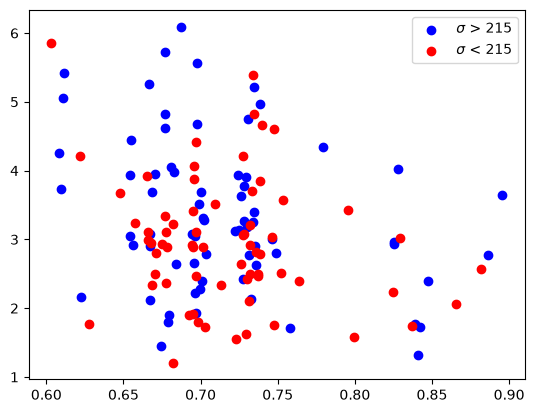

In [24]:
dedup_df = df.drop_duplicates(subset='mms2013_id', keep=False)

high_sigma = dedup_df[dedup_df['dr2_sigma_stars_prime_km_s'] > 215] 
low_sigma = dedup_df[dedup_df['dr2_sigma_stars_prime_km_s'] <= 215]

plt.scatter(high_sigma['dr2_z_spec'], high_sigma['borghi_age_gyr'], c='blue', label = r'$\sigma$ > 215' )
plt.scatter(low_sigma['dr2_z_spec'], low_sigma['borghi_age_gyr'], c='red', label = r'$\sigma$ < 215')
plt.legend()

In [ ]:
high_sigma['z_bin'] = pd.cut(high_sigma['dr2_z_spec'], bins = [0.600, 0.675, 0.750, 0.825, 0.900], right = False, labels = ["1", "2", "3", "4"])

high_sigma_binned = high_sigma.groupby('z_bin').agg({'mms2013_id' : 'count', 'dr2_z_spec': 'mean', 'borghi_age_gyr': 'median'})


high_sigma_binned

,mms2013_id,dr2_z_spec,borghi_age_gyr
z_bin,,,
1,16,0.647717,3.7145
2,43,0.710465,3.2560
3,2,0.768735,3.0325
4,9,0.847765,2.7730


In [31]:
# Bins 1,3 
z_eff_13 = (high_sigma_binned.loc["3", "dr2_z_spec"] + high_sigma_binned.loc["1", "dr2_z_spec"])/2

delta_z_13 = (high_sigma_binned.loc["3", "dr2_z_spec"] - high_sigma_binned.loc["1", "dr2_z_spec"])

delta_t_13 = (high_sigma_binned.loc["3", "borghi_age_gyr"] - high_sigma_binned.loc["1", "borghi_age_gyr"])

print(z_eff_13, delta_z_13, delta_t_13)

H_z_eff_13 = (977.8*-1/(1+z_eff_13)*delta_z_13/delta_t_13)
print(H_z_eff_13)

0.7082260625 0.12101787499999994 -0.6819999999999999
101.57102551751456


In [33]:
# Bins 2, 4 
z_eff_24 = (high_sigma_binned.loc["4", "dr2_z_spec"] + high_sigma_binned.loc["2", "dr2_z_spec"])/2

delta_z_24 = (high_sigma_binned.loc["4", "dr2_z_spec"] - high_sigma_binned.loc["2", "dr2_z_spec"])

delta_t_24 = (high_sigma_binned.loc["4", "borghi_age_gyr"] - high_sigma_binned.loc["2", "borghi_age_gyr"])

print(z_eff_24, delta_z_24, delta_t_24)

H_z_eff_24 = (977.8*-1/(1+z_eff_24)*delta_z_24/delta_t_24)
print(H_z_eff_24)

0.7791147661498707 0.13729957881136945 -0.48299999999999965
156.23133467465652


Note that this is super sensitive. Bins 3 and 4 are tiny, adding one galaxy has huge changes. 

Does LEGA-C simply not have enough galaxies in certain redshift bins? 

Looking at the earlier graph, 0.75-0.825 and 0.825-0.900 are very sparse. They are mostly 0.65-0.75

The paper must use different redshift/dispersion data - it's not reproducible rn.